# SLD Validation Plots

**Kinematic sanity checks on the selected samples.**

This is **notebook 2 of 3**. It loads the per-channel parquet files produced
by [notebook 01](./SLD_01_DataPreparation.ipynb) and produces three diagnostic
plot sets:

| Plot | What it checks |
|---|---|
| Reconstructed $Z$ mass | The selected events really are $Z$ decays — a clean peak around $\sim$91 GeV |
| Hadronic event-shape distributions ($\tau$, $\rho$, $O$, $C$) | The hadronic sample matches the expected $q\bar q g\,\ldots$ topology |
| Leptonic $\cos\theta_T$ split by beam helicity | The polarisation × forward-backward signature that drives $A_\ell$ is present |

This notebook is **read-only** with respect to the selected samples: it does
not modify the parquet files. It also does not perform any measurement; the
asymmetries themselves live in [notebook 03](./SLD_03_Measurements.ipynb).

## 1. Imports and configuration

This notebook reads the parquet files written by notebook 01 from
`$SLD_BASE/datasets/minidst_processed/`. If `SLD_BASE` is unset we fall back
to `./sld`. Match whatever you used when running notebook 01:

```bash
export SLD_BASE=/path/to/your/SLD
```

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import awkward as ak
import numpy as np
import pandas as pd

from sld_resurrect.event_view import EventView, beam_polarisation, event_year
from sld_resurrect.jets import cluster_two_jets
from sld_resurrect.kinematics import (
    build_particles,
    thrust,
    hemisphere_momentum_sums,
    c_parameter,
    oblateness,
    heavy_jet_mass,
)

from quickstats.plots import VariableDistributionPlot

SLD_BASE     = Path(os.environ.get("SLD_BASE", "./sld"))
SELECTED_DIR = SLD_BASE / "datasets/minidst_processed"
PLOTS_DIR    = SLD_BASE / "analysis/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

if not SELECTED_DIR.is_dir():
    raise FileNotFoundError(
        f"Selected-event directory {SELECTED_DIR} does not exist. "
        f"Run notebook 01 (SLD_01_DataPreparation.ipynb) first, or set "
        f"SLD_BASE to a tree that already contains its outputs."
    )
print(f"SLD_BASE     = {SLD_BASE}")
print(f"SELECTED_DIR = {SELECTED_DIR}")
print(f"PLOTS_DIR    = {PLOTS_DIR}")

SLD_BASE     = ./sld
SELECTED_DIR = ./sld/datasets/minidst_processed
PLOTS_DIR    = ./sld/analysis/plots


## 2. Load the selected datasets

Each selected parquet was written by notebook 01 with all banks intact, so we
can re-derive any quantity we need without going back to the raw shards.

In [2]:
CHANNELS: tuple[str, ...] = ("hadronic", "ee", "mumu", "tautau")


def load_selected(channel: str) -> ak.Array:
    """Load one ``sld_{channel}.parquet`` file produced by notebook 01."""
    path = SELECTED_DIR / f"sld_{channel}.parquet"
    arr = ak.from_parquet(str(path))
    print(f"  {channel:<10} {len(arr):>7,} events  ({path.name})")
    return arr


selected = {ch: load_selected(ch) for ch in CHANNELS}

  hadronic   386,053 events  (sld_hadronic.parquet)
  ee          16,569 events  (sld_ee.parquet)
  mumu        14,016 events  (sld_mumu.parquet)
  tautau      17,149 events  (sld_tautau.parquet)


## 3. Shared plot styling

Colour palette, channel labels, and the save helper live here so the three
plot sets read consistently.

In [3]:
CHANNEL_LABELS: dict[str, str] = {
    'qq':     r'$Z \rightarrow q\bar{q}$',
    'ee':     r'$Z \rightarrow e^+e^-$',
    'mumu':   r'$Z \rightarrow \mu^+\mu^-$',
    'tautau': r'$Z \rightarrow \tau^+\tau^-$',
}

CHANNEL_COLORS: dict[str, str] = {
    'qq':     'hdbs:starcommandblue',
    'ee':     'hdbs:starcommandblue',
    'mumu':   'hh:darkpink',
    'tautau': 'hh:darkyellow',
}

POLARISATION_LABELS: dict[str, str] = {
    'left':  r'Left polarized $e^-$ beam',
    'right': r'Right polarized $e^-$ beam',
}
POLARISATION_COLORS: tuple[str, str] = (
    'hdbs:starcommandblue',  # left
    'hh:darkpink',           # right
)

# Center axis labels (used by every panel).
CENTER_AXIS_STYLES: dict = {
    'xlabel': {'loc': 'center'},
    'ylabel': {'loc': 'center'},
}


def save_plot(plotter: VariableDistributionPlot, name: str) -> Path:
    """Save the plotter's current figure as a PDF in PLOTS_DIR."""
    out_path = PLOTS_DIR / f"{name}.pdf"
    plotter.figure.savefig(out_path, bbox_inches='tight')
    print(f"  Saved {out_path}")
    return out_path

## 4. Build particles and cluster jets

For the leptonic channels we just need particle 4-vectors. For the hadronic
$Z$ candidate we also need Durham jets (the hadronic $Z$ is reconstructed as
the sum of the two leading Durham jets).

In [4]:
particles = {ch: build_particles(selected[ch]) for ch in CHANNELS}
had_jets, _ = cluster_two_jets(particles['hadronic'])
had_z = ak.sum(had_jets, axis=1)
print(f"Built particle collections; clustered {len(had_jets):,} hadronic events.")

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
Built particle collections; clustered 386,053 hadronic events.


## 5. Reconstructed $Z$ mass

The reconstructed $Z$ candidate is built differently for the two channel
classes:

* **Hadronic** — sum the two leading Durham jets.
* **Leptonic** — sum the two thrust-hemisphere charged-track 4-vectors. No
  jet clustering needed.

A sharp peak around $m_Z \approx 91.2$ GeV is the standard sanity check that
the selection is delivering a clean $Z$ sample. The leptonic $ee$ and $\mu\mu$
channels recover $m_Z$ accurately; the hadronic peak is shifted $\sim 20$ GeV
low because of energy lost to long-lived neutrals in the LAC and to neutrinos
from semileptonic heavy-flavour decays; the $\tau\tau$ spectrum is broad and
peaks $\sim 40$–$50$ GeV due to $\tau$ daughter neutrinos.

In [5]:
def thrust_hemisphere_z_mass(lep_particles: ak.Array) -> np.ndarray:
    """Reconstruct Z from the sum of the two thrust-hemisphere 4-vectors."""
    _, thrust_vec, _ = thrust(lep_particles)
    hem_fwd, hem_bwd = hemisphere_momentum_sums(lep_particles, thrust_vec)
    return np.asarray((hem_fwd + hem_bwd).mass)


mZ_data: dict[str, np.ndarray] = {
    'qq':     np.asarray(had_z.m),
    'ee':     thrust_hemisphere_z_mass(particles['ee']),
    'mumu':   thrust_hemisphere_z_mass(particles['mumu']),
    'tautau': thrust_hemisphere_z_mass(particles['tautau']),
}
mZ_dfs = {ch: pd.DataFrame({'mZ': v}) for ch, v in mZ_data.items()}

In [6]:
def make_z_mass_plotter(dfs: dict[str, pd.DataFrame]) -> VariableDistributionPlot:
    """Build the VariableDistributionPlot used for the m_Z panels."""
    styles = {
        **CENTER_AXIS_STYLES,
        'hist': {'histtype': 'stepfilled', 'edgecolor': 'k', 'alpha': 0.5},
        'bar': {'hatch': '///', 'facecolor': 'none', 'edgecolor': 'k'},
        'legend': {'loc': 'upper left'},
    }
    label_map = {**CHANNEL_LABELS,
                 'qq.error': 'Stat. Uncertainty',
                 'ee.error': 'Stat. Uncertainty'}
    return VariableDistributionPlot(
        dfs,
        styles=styles,
        config={'isolate_error_legend': True},
        label_map=label_map,
        color_map=CHANNEL_COLORS,
    )


mZ_plotter = make_z_mass_plotter(mZ_dfs)
mZ_kwargs = dict(
    xlabel=r'$m_Z^{\text{reco}}$', unit='GeV',
    bin_range=(0, 120), bins=24,
    normalize=False, xmin=0, ymin=0.1, ypad=0.15,
)

  Saved ./sld/analysis/plots/mZ_hadronic.pdf


PosixPath('./sld/analysis/plots/mZ_hadronic.pdf')

<Figure size 640x480 with 0 Axes>

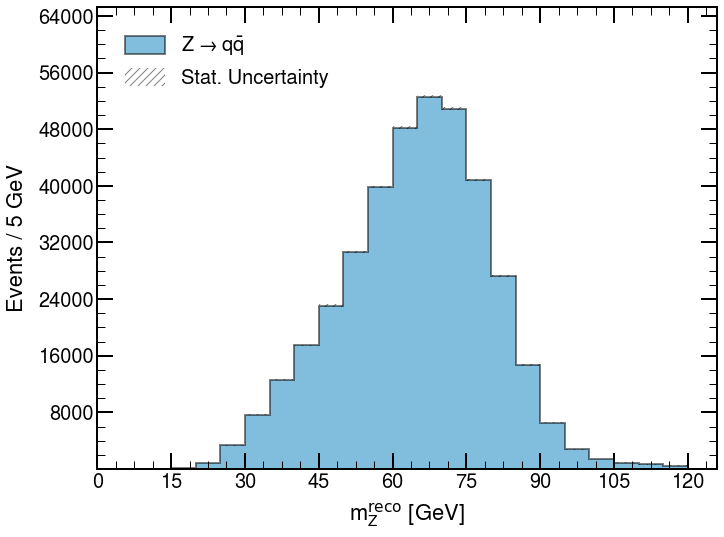

In [7]:
mZ_plotter.draw('mZ', targets=['qq'], **mZ_kwargs)
save_plot(mZ_plotter, 'mZ_hadronic')

  Saved ./sld/analysis/plots/mZ_leptonic.pdf


PosixPath('./sld/analysis/plots/mZ_leptonic.pdf')

<Figure size 640x480 with 0 Axes>

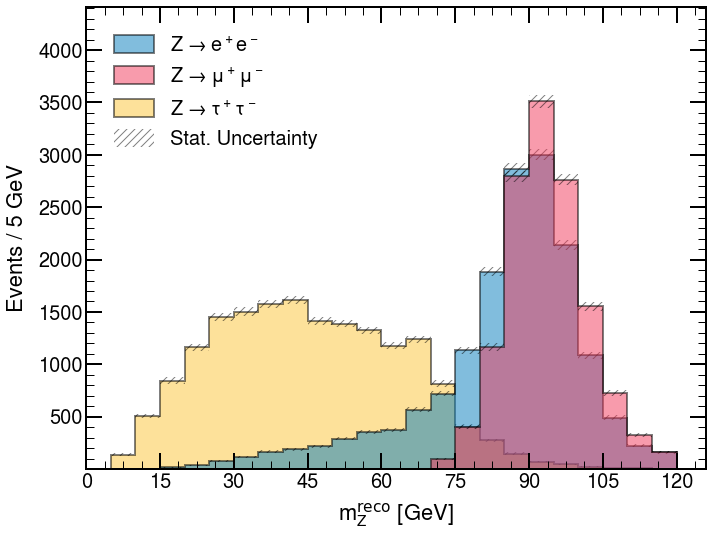

In [8]:
mZ_plotter.draw(
    'mZ',
    targets=['tautau', 'ee', 'mumu'],
    legend_order=['ee', 'mumu', 'tautau', 'ee.error'],
    **mZ_kwargs,
)
save_plot(mZ_plotter, 'mZ_leptonic')

## 6. Hadronic event-shape distributions

The four observables below describe how the energy of a hadronic event is
geometrically distributed. They are sensitive to QCD radiation and to the
strength of the strong coupling.

| Symbol | Definition | Probes |
|---|---|---|
| $\tau = 1 - T$ | Departure from the two-jet limit ($T = 1$ is perfect back-to-back) | Hard gluon radiation |
| $\rho = M_H^2 / E_{\text{vis}}^2$ | Heaviness of the heavier hemisphere | Asymmetric hard QCD radiation |
| $O = T_{\text{maj}} - T_{\text{min}}$ | Oblateness — flatness perpendicular to the thrust axis | Three-jet planar topologies |
| $C = 3(\lambda_1\lambda_2 + \lambda_2\lambda_3 + \lambda_3\lambda_1)$ | $C$-parameter from the linearised momentum tensor | Multi-jet radiation |

All four are plotted as normalised differential cross sections
$(1/\sigma_t)\, d\sigma/dX$ with bin edges that follow SLD's published binning
(finer near the two-jet limit, coarser in the hard-radiation tail).

In [9]:
# Build the four event-shape observables on the hadronic sample.
hadronic_particles = particles['hadronic']
thrust_value, thrust_vec, _ = thrust(hadronic_particles)

shape_df = pd.DataFrame({
    'tau':        ak.to_numpy(1.0 - thrust_value),
    'rho':        ak.to_numpy(heavy_jet_mass(hadronic_particles, thrust_vec)[0]),
    'oblateness': ak.to_numpy(oblateness(hadronic_particles, thrust_vec)),
    'C':          ak.to_numpy(c_parameter(hadronic_particles)),
})

# Custom bin edges follow SLD's published differential distributions.
SHAPE_BINNING: dict[str, np.ndarray] = {
    'tau':        np.array([0.0, 0.02, 0.04, 0.06, 0.08, 0.12, 0.16, 0.20, 0.26, 0.32, 0.38, 0.44]),
    'rho':        np.array([0.0, 0.02, 0.04, 0.08, 0.12, 0.18, 0.24, 0.32, 0.40]),
    'oblateness': np.array([0.0, 0.02, 0.04, 0.08, 0.12, 0.18, 0.24, 0.32, 0.40, 0.50]),
    'C':          np.array([0.0, 0.04, 0.08, 0.12, 0.18, 0.24, 0.32, 0.40, 0.52, 0.64, 0.76, 0.88, 1.0]),
}

SHAPE_AXIS_LABELS: dict[str, tuple[str, str]] = {
    'tau':        (r'$\mathit{\tau}$',
                   r'$1/\mathit{\sigma_t} \, d\mathit{\sigma}/d\mathit{\tau}$'),
    'rho':        (r'$\mathit{\rho}$',
                   r'$1/\mathit{\sigma_t} \, d\mathit{\sigma}/d\mathit{\rho}$'),
    'oblateness': (r'$\mathit{O}$',
                   r'$1/\mathit{\sigma_t} \, d\mathit{\sigma}/d\mathit{O}$'),
    'C':          (r'$\mathit{C}$',
                   r'$1/\mathit{\sigma_t} \, d\mathit{\sigma}/d\mathit{C}$'),
}

  Saved ./sld/analysis/plots/tau.pdf


<Figure size 640x480 with 0 Axes>

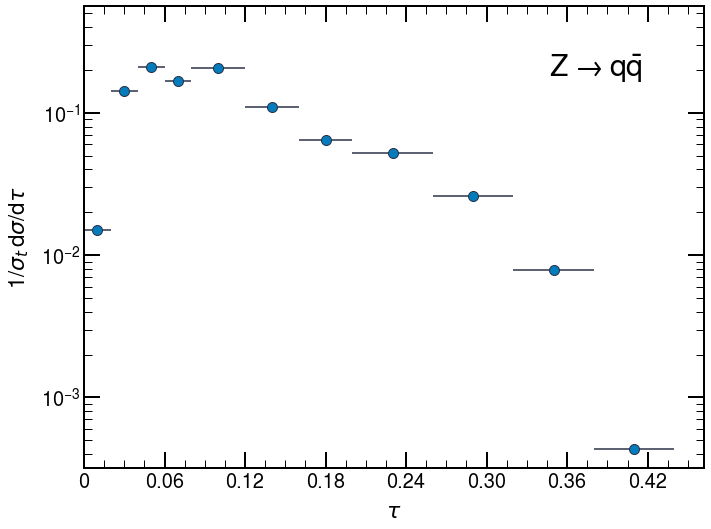

  Saved ./sld/analysis/plots/rho.pdf


<Figure size 640x480 with 0 Axes>

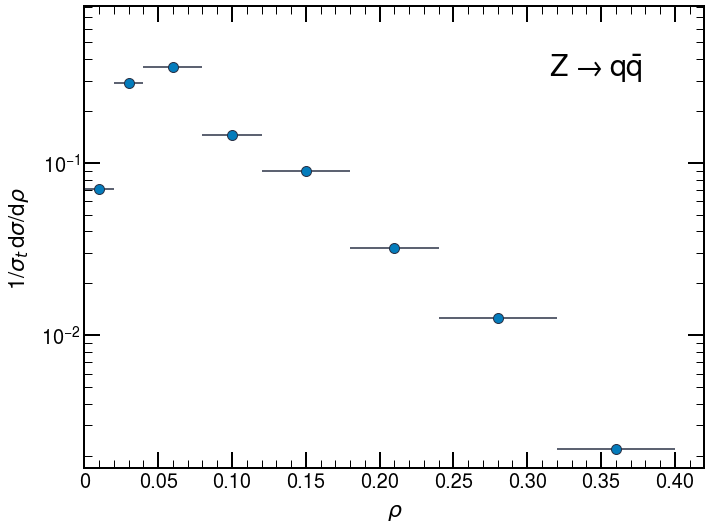

  Saved ./sld/analysis/plots/oblateness.pdf


<Figure size 640x480 with 0 Axes>

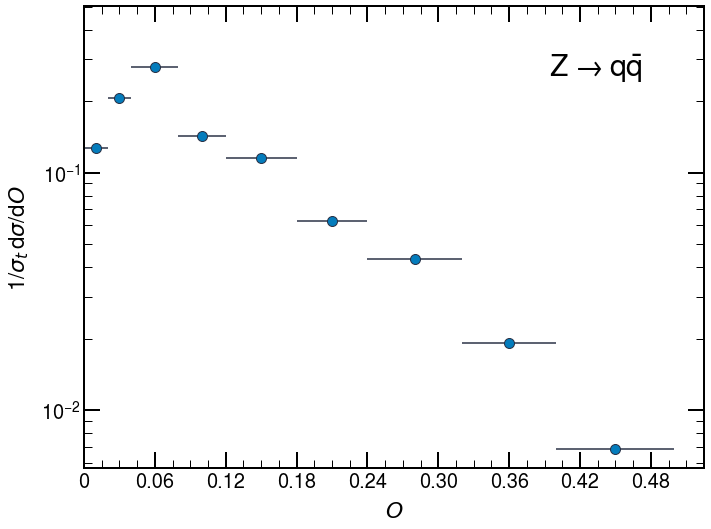

  Saved ./sld/analysis/plots/C.pdf


<Figure size 640x480 with 0 Axes>

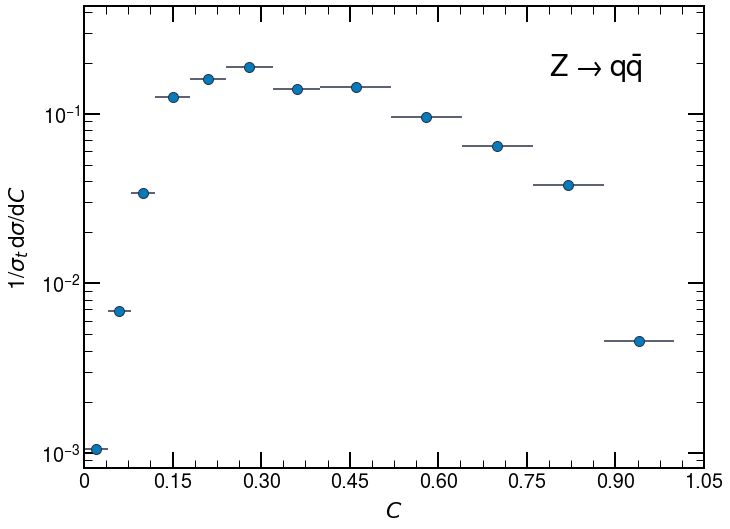

In [10]:
import matplotlib.pyplot as plt

def make_event_shape_plotter(df: pd.DataFrame) -> VariableDistributionPlot:
    """Plotter for the four hadronic event-shape distributions."""
    styles = {
        **CENTER_AXIS_STYLES,
        'errorbar': {
            'markerfacecolor': 'hdbs:starcommandblue',
            'markeredgecolor': 'hdbs:spacecadet',
            'ecolor': 'hdbs:spacecadet',
            'elinewidth': 1.5,
        },
    }
    return VariableDistributionPlot(
        df,
        styles=styles,
        config={'plot_format': 'errorbar', 'show_xerr': True},
    )


def draw_event_shape(plotter: VariableDistributionPlot, column: str) -> None:
    """Draw and save one event-shape panel."""
    xlabel, ylabel = SHAPE_AXIS_LABELS[column]
    plotter.draw(
        column,
        xlabel=xlabel, ylabel=ylabel,
        bins=SHAPE_BINNING[column],
        logy=True, ypad=0.1, xmin=0,
    )
    save_plot(plotter, column)


event_shape_plotter = make_event_shape_plotter(shape_df)
event_shape_plotter.add_text(CHANNEL_LABELS['qq'], x=0.75, y=0.9, fontsize=30)

for column in ('tau', 'rho', 'oblateness', 'C'):
    draw_event_shape(event_shape_plotter, column)
    plt.show()

## 7. Leptonic $\cos\theta_T$ split by beam helicity

For the leptonic channels the relevant geometric observable is

$$ \cos\theta \;=\; \hat n_T \cdot \hat z, $$

where $\hat n_T$ is the **charge-oriented** thrust axis (pointing along the
positive-net-charge hemisphere, i.e. the $\ell^+$ momentum) and $\hat z$ is
the electron-beam direction. At the $Z$ pole the polarised differential
cross section reads

$$ \frac{1}{\sigma}\,\frac{d\sigma}{d\cos\theta}
   \;\propto\;
   (1 + \cos^2\theta)\,(1 - \mathcal P_e A_e)
   \;+\;
   2\cos\theta\,(A_e - \mathcal P_e)\,A_\ell. $$

The $\cos\theta$ asymmetry between left- and right-polarised electron beams
isolates the final-state coupling $A_\ell$ (with the initial-state $A_e$
absorbed into $\mathcal P_e$). Plotting $\cos\theta$ separately for the two
beam helicities is the most direct visualisation of the asymmetry that
notebook 03 quantifies. We restrict to the **1997–98** year-group because
that is where the leptonic statistics live.

In [11]:
def helicity_masks(arr: ak.Array) -> dict[str, np.ndarray]:
    """Boolean masks selecting left/right-polarised events with valid polarisation."""
    pol, _, valid = beam_polarisation(arr)
    return {
        'valid': valid,
        'left':  valid & (pol < 0),
        'right': valid & (pol > 0),
    }


def cos_theta_by_helicity(
    channel: str,
    year_in: tuple[int, ...] = (1997, 1998),
) -> dict[str, np.ndarray]:
    """Return ``{'left': ..., 'right': ...}`` cos(theta_T) arrays.

    The thrust axis is the charge-oriented one, so its z-component is
    cos(theta) of the leading-track-system relative to the electron beam.
    """
    arr = selected[channel]
    # An observables-only view with the preset's track-quality model; no
    # cuts are needed since we run on the already-selected slice.
    view = EventView.from_preset(f"leptonic_{channel}", arr, particles[channel])
    cos_theta = view.get('thrust_vec_charged')[:, 2]

    hel = helicity_masks(arr)
    year_mask = np.isin(event_year(arr), year_in)
    return {
        'left':  cos_theta[hel['left']  & year_mask],
        'right': cos_theta[hel['right'] & year_mask],
    }


cos_theta_data = {
    ch: cos_theta_by_helicity(ch) for ch in ('ee', 'mumu', 'tautau')
}

  Saved ./sld/analysis/plots/cos_theta_ee.pdf


<Figure size 640x480 with 0 Axes>

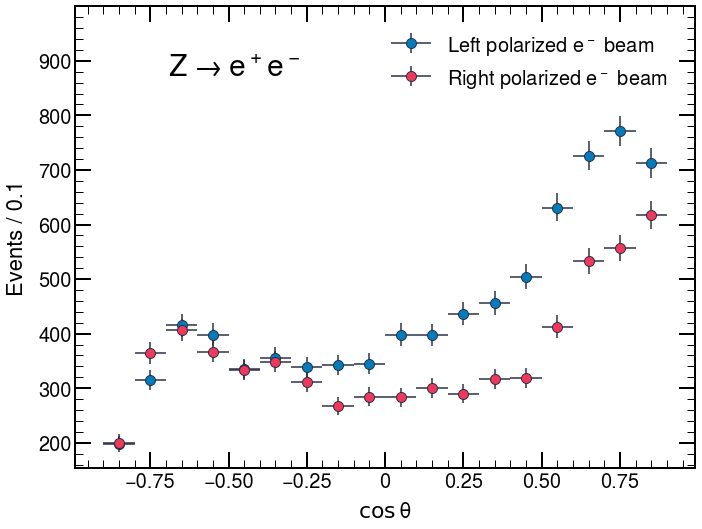

  Saved ./sld/analysis/plots/cos_theta_mumu.pdf


<Figure size 640x480 with 0 Axes>

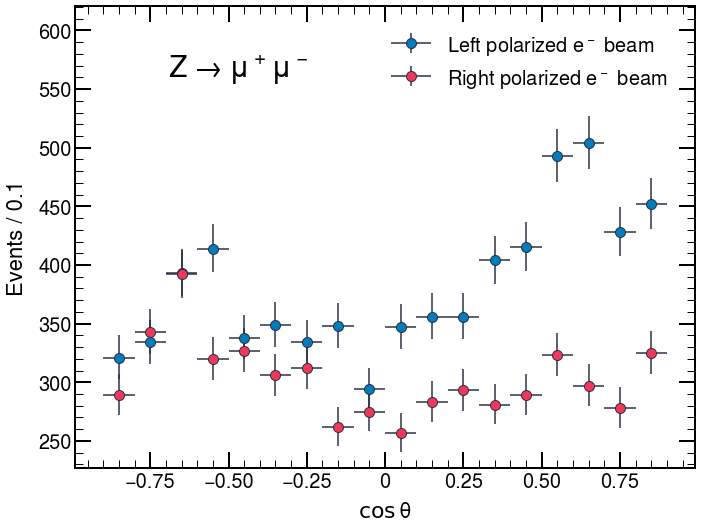

  Saved ./sld/analysis/plots/cos_theta_tautau.pdf


<Figure size 640x480 with 0 Axes>

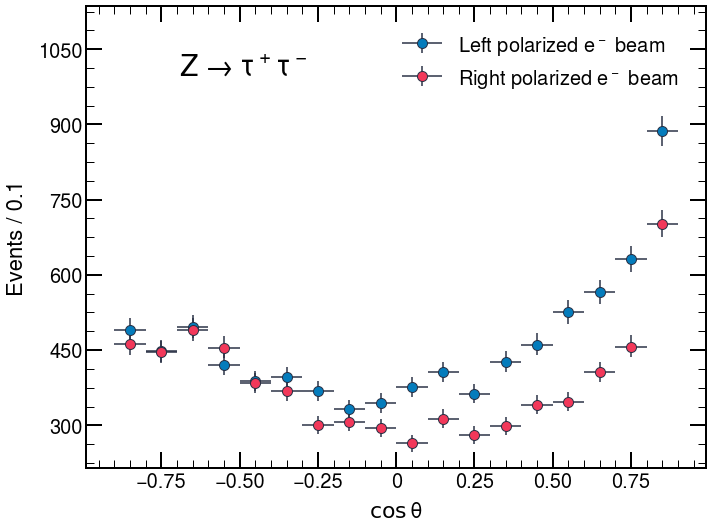

In [12]:
import matplotlib.pyplot as plt

def make_cos_theta_plotter(
    cos_theta_per_helicity: dict[str, np.ndarray],
) -> VariableDistributionPlot:
    """Plotter for left/right polarised cos(theta) overlays of one channel."""
    dfs = {h: pd.DataFrame({'cos_theta': v}) for h, v in cos_theta_per_helicity.items()}
    styles = {
        **CENTER_AXIS_STYLES,
        'errorbar': {
            'markeredgecolor': 'hdbs:spacecadet',
            'ecolor': 'hdbs:spacecadet',
            'elinewidth': 1.5,
        },
    }
    return VariableDistributionPlot(
        dfs,
        config={'plot_format': 'errorbar', 'show_xerr': True},
        styles=styles,
        label_map=POLARISATION_LABELS,
        color_cycle=list(POLARISATION_COLORS),
    )


def draw_cos_theta(channel: str) -> None:
    """One cos(theta) panel for ``channel`` ('ee', 'mumu', or 'tautau')."""
    plotter = make_cos_theta_plotter(cos_theta_data[channel])
    plotter.reset_artists()
    plotter.add_text(CHANNEL_LABELS[channel], x=0.15, y=0.9, fontsize=30)
    plotter.draw(
        'cos_theta',
        xlabel=r'$\cos\theta$',
        targets=['left', 'right'],
        normalize=False,
        bin_range=(-0.9, 0.9), bins=18, ypad=0.2,
    )
    save_plot(plotter, f'cos_theta_{channel}')


for ch in ('ee', 'mumu', 'tautau'):
    draw_cos_theta(ch)
    plt.show()

## 8. Outputs

PDFs written to `PLOTS_DIR`:

* `mZ_hadronic.pdf`, `mZ_leptonic.pdf`
* `tau.pdf`, `rho.pdf`, `oblateness.pdf`, `C.pdf`
* `cos_theta_ee.pdf`, `cos_theta_mumu.pdf`, `cos_theta_tautau.pdf`

Once these look as expected, proceed to
[notebook 03 — Asymmetry measurements](./SLD_03_Measurements.ipynb)
to extract $A_{LR}$ and $A_\ell$.